Для линейной регрессии
  Среднее X (площадь): 2880.7232
  Среднее Y (цена): 338045.2882
  Ковариация Cov(X,Y): 136155591.6240
  Дисперсия Var(X): 1401838.7561

Уравнение регрессии: y = 58250.93 + 97.13 * x
Для квадратичной регрессии
  Σx = 288072.32
  Σx² = 970040491.11
  Σx³ = 3620615280829.21
  Σx⁴ = 14418395651378770.00
  Σy = 33804528.82
  Σxy = 110997049599.24
  Σx²y = 408669002066727.75

Определитель матрицы A: 1.952467e+24

Уравнение регрессии: y = 84680.45 + 75.72 * X + 0.003632 * X²


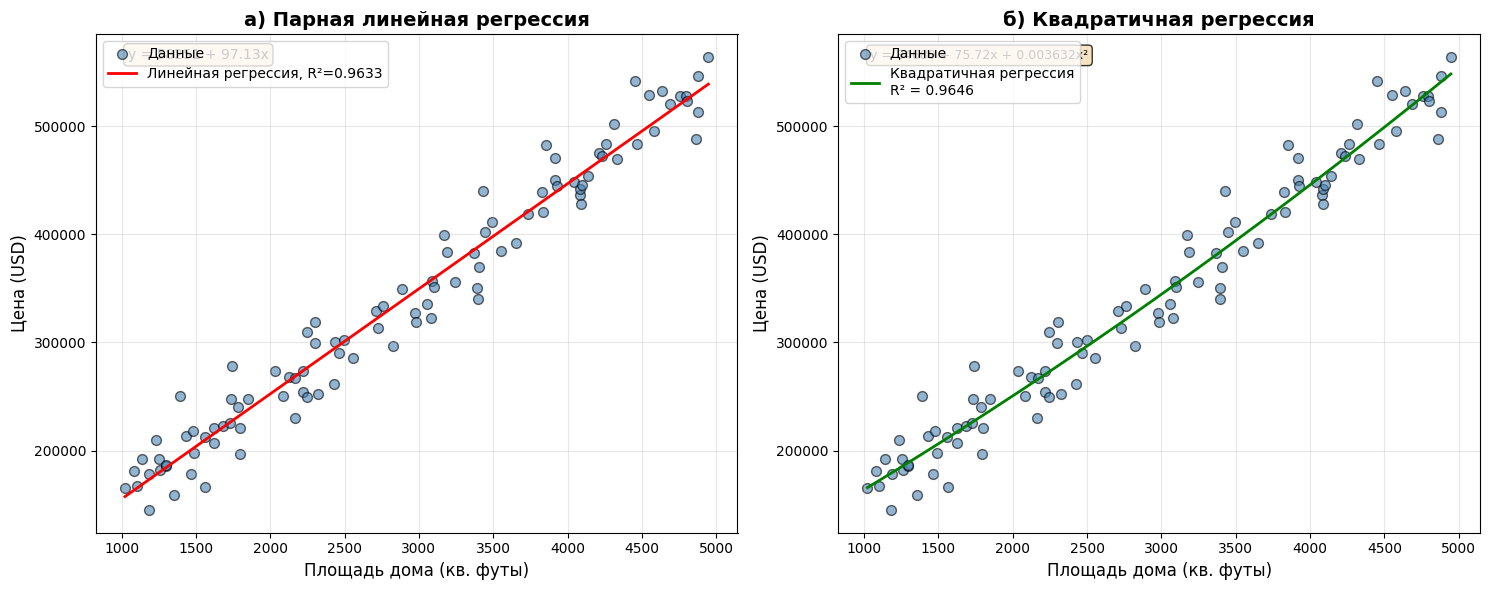


Линейная модель R² = 0.963279 (96.33%)
Квадратичная модель R² = 0.964617 (96.46%)


In [ ]:
#Задание 3
#ссылка на базу данных: https://www.kaggle.com/datasets/hussainnasirkhan/linear-regression-with-one-variable/data?select=house_prices.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('house_prices.csv')
X = df['Size_sqft'].values
y = df['Price_USD'].values
n = len(X)

#парная линейная регрессия
mean_x = np.sum(X) / n
mean_y = np.sum(y) / n

cov_xy = np.sum((X - mean_x) * (y - mean_y)) / n
var_x = np.sum((X - mean_x) ** 2) / n

beta1_lin = cov_xy / var_x
beta0_lin = mean_y - beta1_lin * mean_x

print("Для линейной регрессии")
print(f"  Среднее X (площадь): {mean_x:.4f}")
print(f"  Среднее Y (цена): {mean_y:.4f}")
print(f"  Ковариация Cov(X,Y): {cov_xy:.4f}")
print(f"  Дисперсия Var(X): {var_x:.4f}")
print(f"\nУравнение регрессии: y = {beta0_lin:.2f} + {beta1_lin:.2f} * x")

y_pred_lin = beta0_lin + beta1_lin * X
residuals_lin = y - y_pred_lin

#визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1 = axes[0]
ax1.scatter(X, y, alpha=0.6, s=50, c='steelblue', edgecolors='black', label='Данные')
ax1.plot(X, y_pred_lin, 'r-', linewidth=2, label=f'Линейная регрессия, R²={r2_lin:.4f}')
ax1.set_xlabel('Площадь дома (кв. футы)', fontsize=12)
ax1.set_ylabel('Цена (USD)', fontsize=12)
ax1.set_title('а) Парная линейная регрессия', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'y = {beta0_lin:.0f} + {beta1_lin:.2f}x',
         transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))



#парная квадратичная регрессия
X1 = X
X2 = X ** 2

sum_x = np.sum(X)
sum_x2 = np.sum(X ** 2)
sum_x3 = np.sum(X ** 3)
sum_x4 = np.sum(X ** 4)
sum_y = np.sum(y)
sum_xy = np.sum(X * y)
sum_x2y = np.sum((X ** 2) * y)

print("Для квадратичной регрессии")
print(f"  Σx = {sum_x:.2f}")
print(f"  Σx² = {sum_x2:.2f}")
print(f"  Σx³ = {sum_x3:.2f}")
print(f"  Σx⁴ = {sum_x4:.2f}")
print(f"  Σy = {sum_y:.2f}")
print(f"  Σxy = {sum_xy:.2f}")
print(f"  Σx²y = {sum_x2y:.2f}")

A = np.array([
    [n, sum_x, sum_x2],
    [sum_x, sum_x2, sum_x3],
    [sum_x2, sum_x3, sum_x4]
])

B = np.array([sum_y, sum_xy, sum_x2y])

det_A = np.linalg.det(A)
print(f"\nОпределитель матрицы A: {det_A:.6e}")


beta = np.linalg.solve(A, B)
beta0_quad, beta1_quad, beta2_quad = beta

print(f"\nУравнение регрессии: y = {beta0_quad:.2f} + {beta1_quad:.2f} * X + {beta2_quad:.6f} * X²")


ax2 = axes[1]
ax2.scatter(X, y, alpha=0.6, s=50, c='steelblue', edgecolors='black', label='Данные')
X_sorted = np.sort(X)
y_pred_quad_sorted = beta0_quad + beta1_quad * X_sorted + beta2_quad * (X_sorted ** 2)
ax2.plot(X_sorted, y_pred_quad_sorted, 'green', linewidth=2, label=f'Квадратичная регрессия\nR² = {r2_quad:.4f}')
ax2.set_xlabel('Площадь дома (кв. футы)', fontsize=12)
ax2.set_ylabel('Цена (USD)', fontsize=12)
ax2.set_title('б) Квадратичная регрессия', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, f'y = {beta0_quad:.0f} + {beta1_quad:.2f}x + {beta2_quad:.6f}x²',
         transform=ax2.transAxes, fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

#R2 score

y_pred_lin = beta0_lin + beta1_lin * X
y_pred_quad = beta0_quad + beta1_quad * X + beta2_quad * (X ** 2)

ss_tot = np.sum((y - mean_y) ** 2)
ss_res_lin = np.sum((y - y_pred_lin) ** 2)
ss_res_quad = np.sum((y - y_pred_quad) ** 2)

r2_lin = 1 - ss_res_lin / ss_tot
r2_quad = 1 - ss_res_quad / ss_tot

print(f"\nЛинейная модель R² = {r2_lin:.6f} ({r2_lin*100:.2f}%)")
print(f"Квадратичная модель R² = {r2_quad:.6f} ({r2_quad*100:.2f}%)")



















# Выводы:

**Интерпретация коэффициентов парной линейной регрессии:** при увеличении площади дома на один кв. фут, цена дома возрастёт на 97,13 USD; свободный член, равный 58250.93 отображает предполагаемую цену дома с нулевой площадью, однако в реальной жизни это значение не имеет практического смысла.

**Интерпретация коэффициентов парной квадратичной регрессии:** свободный член, равный 84680.45 отображает предполагаемую цену дома с нулевой площадью, однако в реальной жизни это значение не имеет практического смысла; коэффициент при х, равный 75.72 отражает эффект от увеличения площади жилья на 1 кв.фут. Коэффициент при х^2, равный 0.003632 больше нуля, что говорит о том, что каждый дополнительный кв.фут увеличивает цену сильнее, чем предыдущий.

**Интерпретация коэффицентов детерминации для каждой модели:** для линейной модели R^2 = 0.963279, что говорит о том, что модель объясняет 96,32% вариации цен на жилье. Для квадратичной модели R^2 = 0.964617, что говорит о том, что квадратичная модель объясняет 96,46% вариации цен на жилье. Несмотря на небольшую разницу, квадратичная модель чуть лучше описывает зависимость цены жилья от площади.
